# Regress doy on temperature

In [1]:
url <- "https://sites.ecmwf.int/data/climatepulse/data/series/era5_daily_series_2t_global.csv"

d <- read.csv(url, comment.char = "#")

d$date <- as.Date(d$date)
d$year <- as.integer(format(d$date, "%Y"))

# March 1 = day 0
march1 <- as.Date(paste0(d$year, "-03-01"))

d$x <- as.integer(d$date - march1)

# Move January and February to the end of the March-February year
leap <- (d$year %% 4 == 0 & d$year %% 100 != 0) |
        (d$year %% 400 == 0)

d$x[d$x < 0] <- d$x[d$x < 0] + ifelse(leap[d$x < 0], 366, 365)

# Spline hinges
d$h100 <- pmax(0, d$x - 100)
d$h150 <- pmax(0, d$x - 150)
d$h200 <- pmax(0, d$x - 200)
d$h266 <- pmax(0, d$x - 266)
d$h316 <- pmax(0, d$x - 316)

# Fit actual 2t observations
fit <- lm(X2t ~ x + h100 + h150 + h200 + h266 + h316, data = d)

In [2]:
summary(fit)


Call:
lm(formula = X2t ~ x + h100 + h150 + h200 + h266 + h316, data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.96097 -0.32496 -0.08715  0.28957  1.54234 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 12.6344176  0.0085715 1474.00   <2e-16 ***
x            0.0307125  0.0001329  231.03   <2e-16 ***
h100        -0.0228730  0.0003414  -66.99   <2e-16 ***
h150        -0.0258890  0.0004559  -56.78   <2e-16 ***
h200        -0.0192706  0.0004077  -47.27   <2e-16 ***
h266         0.0226814  0.0004150   54.66   <2e-16 ***
h316         0.0260683  0.0005596   46.59   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4232 on 31642 degrees of freedom
Multiple R-squared:  0.9164,	Adjusted R-squared:  0.9164 
F-statistic: 5.778e+04 on 6 and 31642 DF,  p-value: < 2.2e-16


In [3]:
coef(fit)

(Intercept)           x        h100        h150        h200        h266 
12.63441757  0.03071255 -0.02287301 -0.02588896 -0.01927058  0.02268140 
       h316 
 0.02606829

In [4]:
# Mean Absolute Error (MAE)
mean(abs(d$X2t - fitted(fit)))

[1] 0.3486724

In [5]:
unique_years <- sort(unique(d$year))
num_years <- length(unique_years)

year_palette <- colorRampPalette(c(
  "#00f8",
  "#04f8",
  "#05f8",
  "#06f8",
  "#08f8",
  "#0af8",
  "#0bf8",
  "#0cf8",
  "#0ff8",
  "#0fb8",
  "#0f98",
  "#0f78",
  "#0f08",
  "#6f08",
  "#7f08",
  "#8f08",
  "#af08",
  "#cf08",
  "#df08",
  "#ef08",
  "#ff08",
  "#fd08",
  "#fc08",
  "#fb08",
  "#f908",
  "#f708",
  "#f608",
  "#f508",
  "#f008"
), alpha = TRUE)

year_colors <- year_palette(num_years)
names(year_colors) <- unique_years

point_colors <- year_colors[as.character(d$year)]

In [6]:
options(repr.plot.width = 12, repr.plot.height = 6)

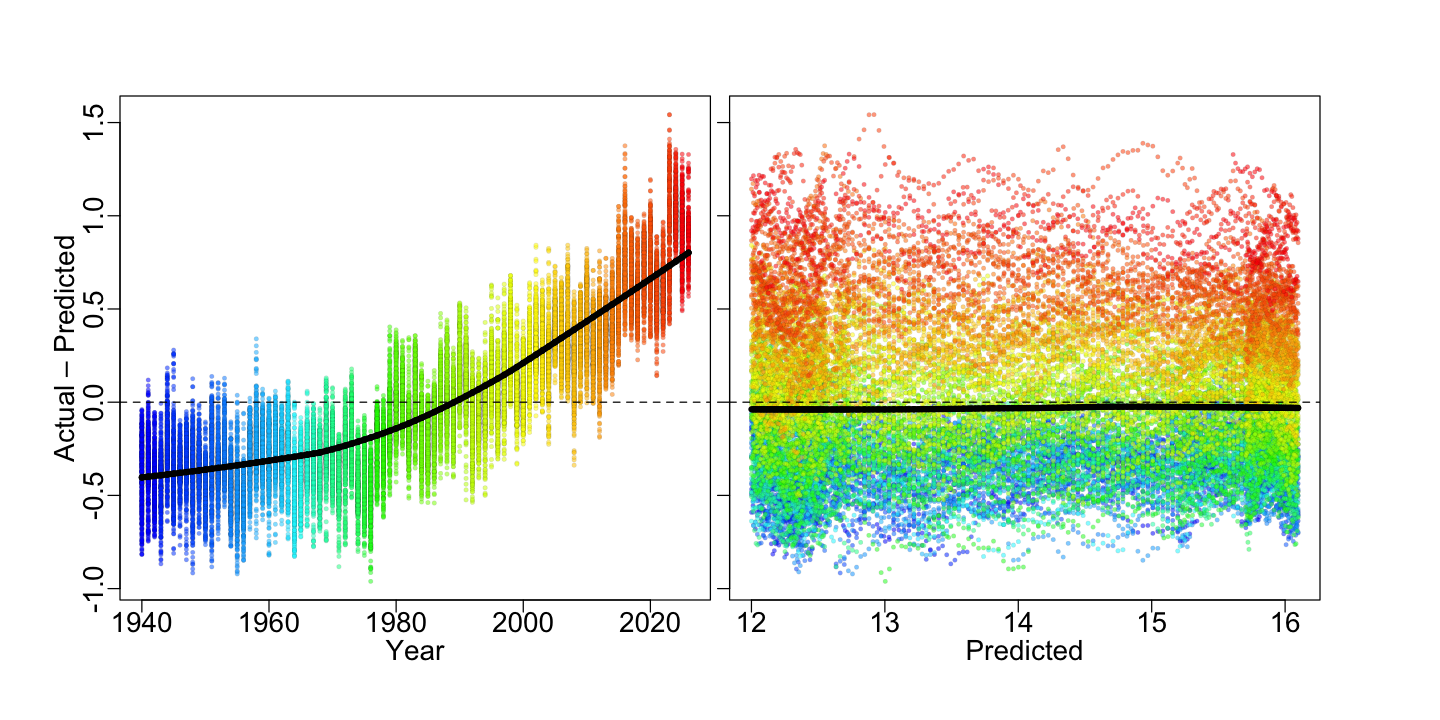

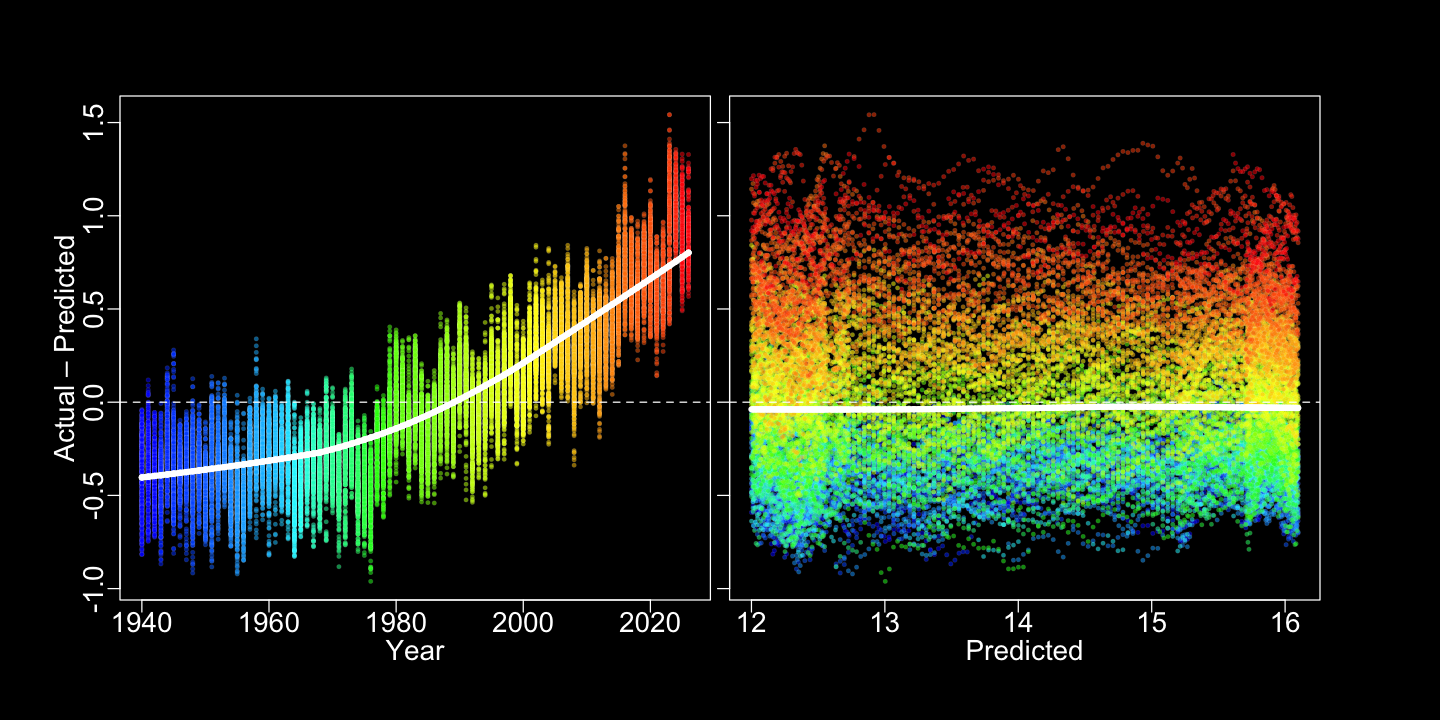

In [7]:
#| fig-width: 8
#| fig-height: 4
#| renderings: [light, dark]
par(
    bg = "#FFFFFF",
    fg = "#000000",
    cex.axis = 1.4,
    cex.lab = 1.4,
    cex.sub = 1.4,
    mfrow = c(1, 2)
)

par(mar = c(5, 5, 4, .4))
plot(
  d$year,
  residuals(fit),
  pch = 21,
  bg = point_colors,
  col = "#0008",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  xlab = "Year",
  ylab = "Actual – Predicted"
)
abline(h = 0, lty = 2)
lines(lowess(d$year, residuals(fit)), lwd = 5)

par(mar = c(5, .4, 4, 5))
plot(
  fitted(fit),
  residuals(fit),
  pch = 21,
  bg = point_colors,
  col = "#0008",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  yaxt = "n",
  xlab = "Predicted",
  ylab = ""
)
axis(2, labels = FALSE)
abline(h = 0, lty = 2)
lines(lowess(fitted(fit), residuals(fit)), lwd = 5)


par(bg = "#000000",
    fg = "#FFFFFF",
    col.axis = "#FFFFFF",
    col.lab = "#FFFFFF",
    col.sub  = "#FFFFFF"
   )

par(mar = c(5, 5, 4, .4))
plot(
  d$year,
  residuals(fit),
  pch = 21,
  bg = point_colors,
  col = "#fff8",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  xlab = "Year",
  ylab = "Actual – Predicted"
)
abline(h = 0, lty = 2)
lines(lowess(d$year, residuals(fit)), lwd = 5)

par(mar = c(5, .4, 4, 5))
plot(
  fitted(fit),
  residuals(fit),
  pch = 21,
  bg = point_colors,
  col = "#fff8",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  yaxt = "n",
  xlab = "Predicted",
  ylab = ""
)
axis(2, labels = FALSE)
abline(h = 0, lty = 2)
lines(lowess(fitted(fit), residuals(fit)), lwd = 5)

In [8]:
fit_year <- lm(X2t ~ x + h100 + h150 + h200 + h266 + h316 + year, data = d)

In [9]:
summary(fit_year)


Call:
lm(formula = X2t ~ x + h100 + h150 + h200 + h266 + h316 + year, 
    data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.86049 -0.14969 -0.00689  0.14524  0.96031 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.582e+01  1.001e-01 -158.08   <2e-16 ***
x            3.071e-02  7.045e-05  435.98   <2e-16 ***
h100        -2.289e-02  1.809e-04 -126.53   <2e-16 ***
h150        -2.571e-02  2.416e-04 -106.42   <2e-16 ***
h200        -1.941e-02  2.160e-04  -89.86   <2e-16 ***
h266         2.253e-02  2.199e-04  102.45   <2e-16 ***
h316         2.616e-02  2.965e-04   88.23   <2e-16 ***
year         1.435e-02  5.040e-05  284.65   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2243 on 31641 degrees of freedom
Multiple R-squared:  0.9765,	Adjusted R-squared:  0.9765 
F-statistic: 1.879e+05 on 7 and 31641 DF,  p-value: < 2.2e-16


In [10]:
dev.new(width = 96, height = 4)

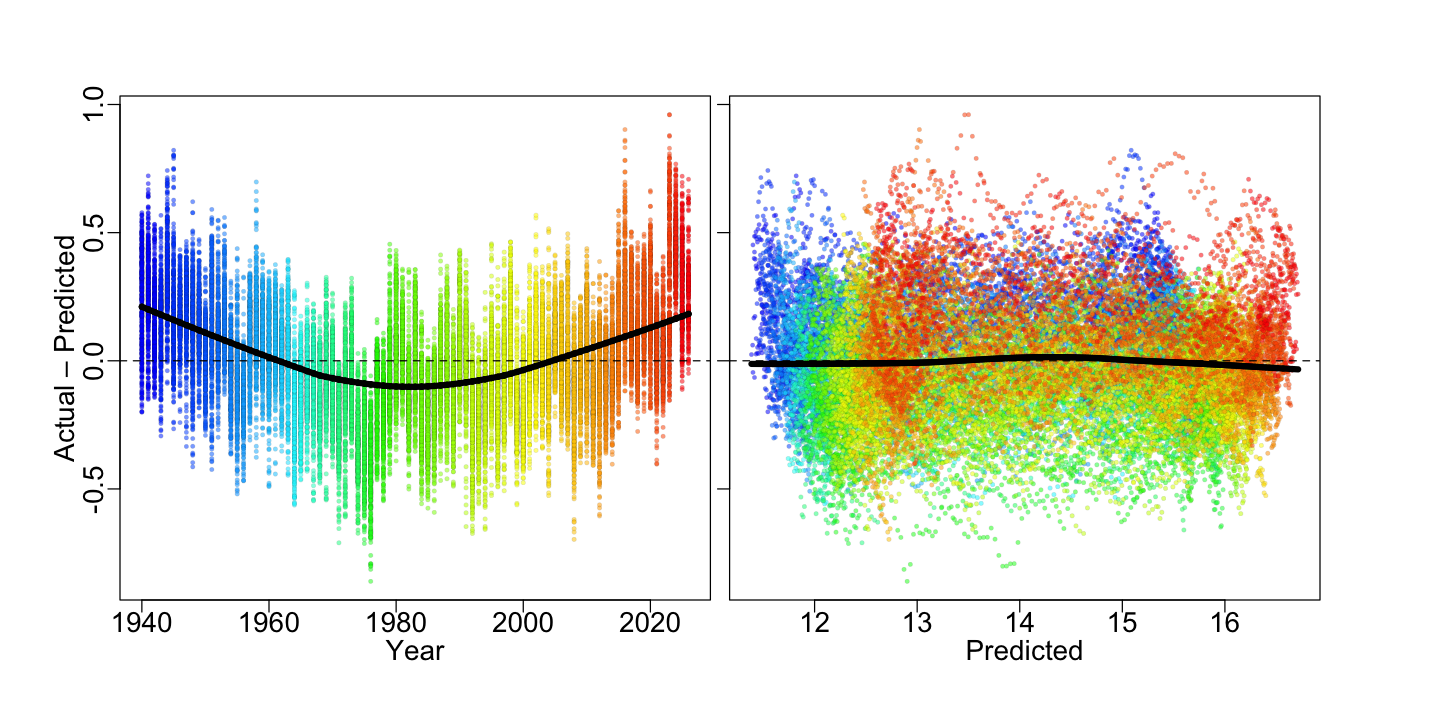

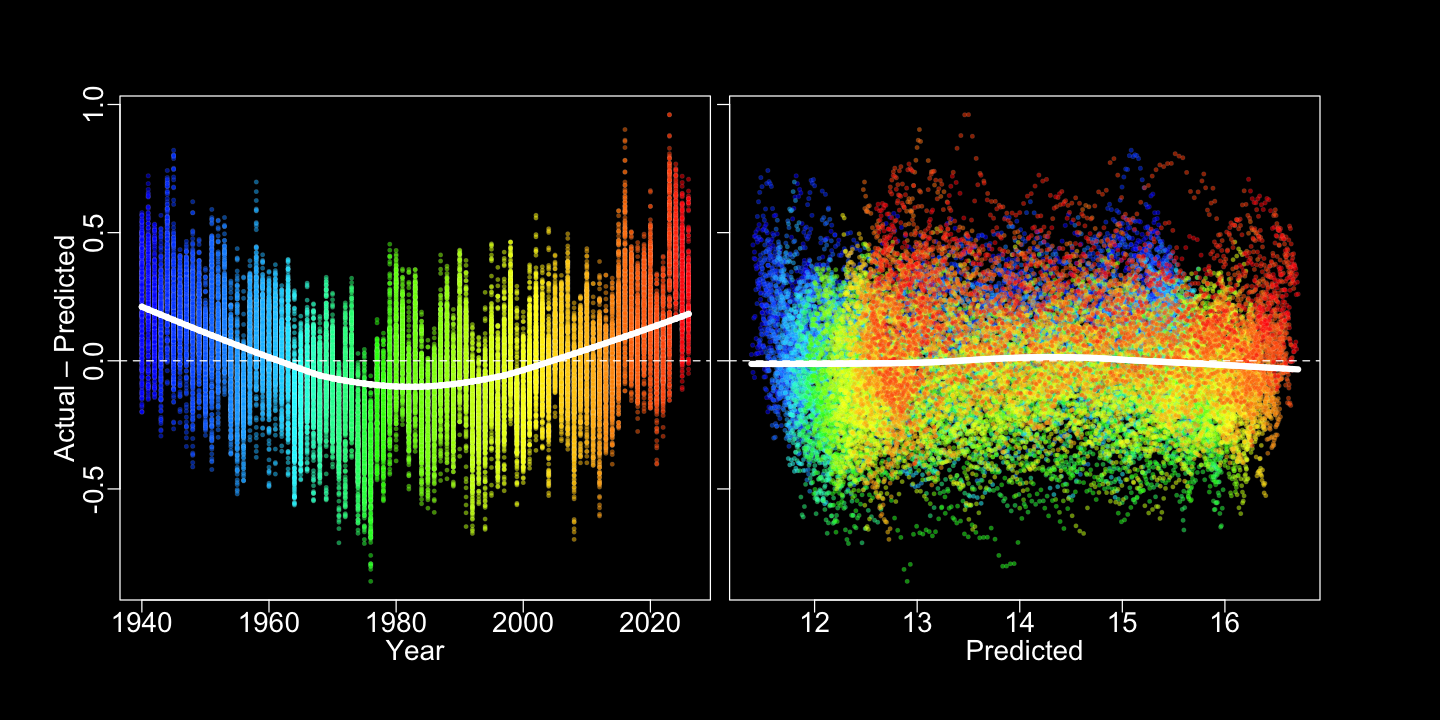

In [11]:
#| fig-width: 8
#| fig-height: 4
#| renderings: [light, dark]
par(
    bg = "#FFFFFF",
    fg = "#000000",
    cex.axis = 1.4,
    cex.lab = 1.4,
    cex.sub = 1.4,
    mfrow = c(1, 2)
)

par(mar = c(5, 5, 4, .4))
plot(
  d$year,
  residuals(fit_year),
  pch = 21,
  bg = point_colors,
  col = "#0008",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  xlab = "Year",
  ylab = "Actual – Predicted"
)
abline(h = 0, lty = 2)
lines(lowess(d$year, residuals(fit_year)), lwd = 5)

par(mar = c(5, .4, 4, 5))
plot(
  fitted(fit_year),
  residuals(fit_year),
  pch = 21,
  bg = point_colors,
  col = "#0008",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  yaxt = "n",
  xlab = "Predicted",
  ylab = ""
)
axis(2, labels = FALSE)
abline(h = 0, lty = 2)
lines(lowess(fitted(fit_year), residuals(fit_year)), lwd = 5)


par(bg = "#000000",
    fg = "#FFFFFF",
    col.axis = "#FFFFFF",
    col.lab = "#FFFFFF",
    col.sub  = "#FFFFFF"
   )

par(mar = c(5, 5, 4, .4))
plot(
  d$year,
  residuals(fit_year),
  pch = 21,
  bg = point_colors,
  col = "#fff8",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  xlab = "Year",
  ylab = "Actual – Predicted"
)
abline(h = 0, lty = 2)
lines(lowess(d$year, residuals(fit_year)), lwd = 5)

par(mar = c(5, .4, 4, 5))
plot(
  fitted(fit_year),
  residuals(fit_year),
  pch = 21,
  bg = point_colors,
  col = "#fff8",
  lwd = 0.1,
  cex = 0.5,
  mgp = c(1.7, 0.5, 0),
  yaxt = "n",
  xlab = "Predicted",
  ylab = ""
)
axis(2, labels = FALSE)
abline(h = 0, lty = 2)
lines(lowess(fitted(fit_year), residuals(fit_year)), lwd = 5)


In [12]:
# Mean Absolute Error (MAE)
mean(abs(d$X2t - fitted(fit_year)))

[1] 0.177837